# Phân tích hiệu năng khối phát hiện khuôn mặt — ONNX Runtime so với NCNN

**Nguồn dữ liệu:** ba lượt đo ngày 03/09/2026, sinh bởi `scripts/benchmark_detect.py`
(chuỗi mã việc `P2-03` → `P2-06` → `P2-06b`):

| Lượt | Tệp | Giờ chạy |
|---|---|---|
| 1 | `results/bench_detect_20260903_2022.csv` | 20:22 |
| 2 | `results/bench_detect_20260903_2040.csv` | 20:40 |
| 3 | `results/bench_detect_20260903_2044.csv` | 20:44 |

Mỗi lượt quét ma trận đầy đủ **12 ô** = {ONNX, NCNN} × {320, 640} × {1, 2, 4 luồng}, mỗi ô 100
khung hình sau 10 khung làm nóng. Tổng **3 600 phép đo**.

> Bản trước của notebook này phân tích `bench_detect_20260819_1453.csv` — 6 ô, chỉ ONNX, đo từ mã
> chưa commit. Bản đó còn trong git tại commit `06f0235`.

---

## ⚠️ Toàn bộ số liệu ở đây đo trên MÁY PHÁT TRIỂN x86-64, không phải Raspberry Pi 5

Theo `.claude/instructions/experiment-protocol.instructions.md` §2, mọi chỉ số FPS đưa vào bảng
đối chiếu chỉ tiêu **bắt buộc** đo trên phần cứng đích. Trường `moi_truong` của cả ba tệp đều là
`pc_x86`.

Có thêm một lý do riêng khiến phép so sánh này không chuyển được sang ARM: **NCNN được tối ưu quanh
tập lệnh vectơ NEON của ARM**, còn trên x86-64 nó đi đường SSE/AVX ít được chăm sóc hơn; ONNX
Runtime thì ngược lại, x86 mới là nơi nó được tối ưu kỹ nhất. Thứ tự nhanh chậm giữa hai backend
hoàn toàn có thể **đảo dấu** khi đổi kiến trúc.

Notebook này vì thế trả lời ba câu hỏi **không** liên quan tới việc chọn backend:

1. Quy trình đo có chạy đúng trên cả 12 ô không
2. Nhiễu đo trên máy phát triển lớn tới mức nào, so với khác biệt cần đo
3. Độ ổn định của hai backend — đại lượng không đảo dấu theo kiến trúc như tốc độ tuyệt đối

## Điều kiện đo — một sai lệch phải nói rõ

Lượt 1 cách lượt 2 **18 phút**, nhưng lượt 2 cách lượt 3 chỉ **4 phút**. Lượt 3 vì thế chạy khi máy
còn ấm từ lượt trước, khác với ý định ban đầu là để mỗi lượt về cùng trạng thái nhiệt. Ghi lại ở
đây thay vì bỏ qua, vì vòng review `P2-03` đã chứng minh trạng thái nhiệt ảnh hưởng tới số đo của
chính máy này.

In [9]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

GOC = Path('..').resolve()
TEP_LUOT = {
    1: GOC / 'results' / 'bench_detect_20260903_2022.csv',
    2: GOC / 'results' / 'bench_detect_20260903_2040.csv',
    3: GOC / 'results' / 'bench_detect_20260903_2044.csv',
}

# Kiểu vẽ tối giản, đọc được khi in đen trắng (latex-visualization)
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 300,
    'font.family': 'serif', 'font.size': 10,
    'axes.grid': True, 'grid.alpha': 0.3, 'axes.axisbelow': True,
})

khung, meta_theo_luot = [], {}
for lot, tep in TEP_LUOT.items():
    d = pd.read_csv(tep)
    d['lot'] = lot
    khung.append(d)
    meta_theo_luot[lot] = json.loads(
        (tep.parent / (tep.stem + '.meta.json')).read_text(encoding='utf-8')
    )

df = pd.concat(khung, ignore_index=True)
backends = sorted(df.backend.unique())
kich_thuoc = sorted(df.imgsz.unique())
luong = sorted(df.threads.unique())

print(len(df), 'dòng đo |', len(backends), 'backend ×', len(kich_thuoc),
      'độ phân giải ×', len(luong), 'mức luồng ×', len(TEP_LUOT), 'lượt')
print('backend:', backends)

3600 dòng đo | 2 backend × 2 độ phân giải × 3 mức luồng × 3 lượt
backend: ['ncnn', 'onnx']


## 1. Kiểm điều kiện của ba tệp trước khi đọc số

Trước khi phân tích, cần biết ba tệp này có đủ điều kiện đưa vào báo cáo hay không. Checklist §9 của
`experiment-protocol` đặt ra các điều kiện đó; ô dưới kiểm từng điều kiện thay vì mặc nhiên tin.

Điều kiện quan trọng nhất liên quan tới **khả năng tái lập**: số đo phải truy ngược được về đúng một
phiên bản mã nguồn. Nếu lúc chạy đo mà mã còn những sửa đổi chưa lưu vào lịch sử git, thì sau này
không ai dựng lại được đúng phiên bản đã sinh ra con số ấy. Trường `git_commit` cho biết phiên bản
nào, còn `git_dirty` cho biết lúc đó còn sửa đổi nào chưa lưu hay không.

### Một cảnh báo về chính trường `git_dirty`

Lượt 1 có `git_dirty` bằng `False`, hai lượt sau bằng `True` — nhưng **mã nguồn không hề đổi giữa ba
lượt**: cả ba cùng một `git_commit`, và không có commit nào được tạo trong 22 phút đó.

Nguyên nhân nằm ở cách script tự kiểm: `_kiem_tra_git_dirty` (`scripts/benchmark_detect.py:347`)
chạy `git status --porcelain` trên **toàn bộ thư mục dự án**, mà lệnh này liệt kê cả những tệp chưa
được git theo dõi. Lượt 1 chạy khi thư mục còn sạch, rồi tự sinh ra hai tệp kết quả; lượt 2 nhìn
thấy hai tệp đó và kết luận rằng có thay đổi chưa lưu.

Nói cách khác, **phép đo trước làm hỏng điều kiện của phép đo sau** — dù thứ sinh ra chỉ là kết quả
đo, không phải mã. Điều `git_dirty` cần trả lời là *"mã sinh ra số đo có nguyên vẹn không"*, chứ
không phải *"thư mục có tệp mới nào không"*.

Vì vậy ô dưới kiểm thêm một điều kiện thay thế, chặt hơn cho mục đích này: **ba lượt có cùng một
`git_commit` hay không**. Nếu cùng, và không có commit nào xen giữa, thì cả ba chạy trên cùng một
phiên bản mã và số liệu vẫn tái lập được.

In [10]:
bang_meta = pd.DataFrame([{
    'lượt': lot,
    'commit': m['git_commit'][:8],
    'sửa đổi chưa lưu': m['git_dirty'],
    'môi trường': m['moi_truong'],
    'ncnn': m['software'].get('ncnn', 'THIẾU'),
    'onnxruntime': m['software'].get('onnxruntime', 'THIẾU'),
    'seed': m['seed'],
    'warmup': m['warmup_frames'],
    'thời lượng (s)': round(m['duration_s'], 1),
} for lot, m in meta_theo_luot.items()])

print(bang_meta.to_string(index=False))
print()

so_o_moi_luot = df.groupby('lot').apply(
    lambda g: len(g.groupby(['backend', 'imgsz', 'threads'])), include_groups=False
)
dieu_kien = {
    'ba lượt chạy trên cùng một phiên bản mã': bang_meta.commit.nunique() == 1,
    'cùng một môi trường': bang_meta['môi trường'].nunique() == 1,
    'meta có ghi phiên bản ncnn': (bang_meta.ncnn != 'THIẾU').all(),
    'cùng một seed chọn ảnh': bang_meta.seed.nunique() == 1,
    'mỗi lượt đủ 12 ô ma trận': bool((so_o_moi_luot == 12).all()),
}
for ten, ok in dieu_kien.items():
    print(('  ĐẠT      ' if ok else '  KHÔNG ĐẠT  ') + ten)

print()
if bang_meta['sửa đổi chưa lưu'].any():
    print('Ghi chú: cột "sửa đổi chưa lưu" bật ở lượt', 
          ', '.join(str(l) for l in bang_meta.loc[bang_meta['sửa đổi chưa lưu'], 'lượt']),
          '- xem phần giải thích phía trên.')
    print('Cả ba lượt cùng commit', bang_meta.commit.iloc[0],
          'nên khác biệt đó đến từ tệp kết quả mới sinh, không từ mã nguồn.')

 lượt   commit  sửa đổi chưa lưu môi trường         ncnn onnxruntime  seed  warmup  thời lượng (s)
    1 743640b0             False     pc_x86 1.0.20260526      1.20.1    42      10           107.7
    2 743640b0              True     pc_x86 1.0.20260526      1.20.1    42      10           104.2
    3 743640b0              True     pc_x86 1.0.20260526      1.20.1    42      10           101.2

  ĐẠT      ba lượt chạy trên cùng một phiên bản mã
  ĐẠT      cùng một môi trường
  ĐẠT      meta có ghi phiên bản ncnn
  ĐẠT      cùng một seed chọn ảnh
  ĐẠT      mỗi lượt đủ 12 ô ma trận

Ghi chú: cột "sửa đổi chưa lưu" bật ở lượt 2, 3 - xem phần giải thích phía trên.
Cả ba lượt cùng commit 743640b0 nên khác biệt đó đến từ tệp kết quả mới sinh, không từ mã nguồn.


## 2. Bảng tổng hợp — hai kiểu dao động cần tách bạch

Số đo dao động vì hai nguyên nhân hoàn toàn khác nhau, và gộp chúng lại sẽ dẫn tới kết luận sai:

| Kiểu dao động | Đo bằng | Cho biết điều gì |
|---|---|---|
| **Trong cùng một lượt** | độ lệch chuẩn của 100 khung hình | mô hình xử lý đều tay hay lúc nhanh lúc chậm |
| **Giữa các lượt** | khoảng cách giữa lượt nhanh nhất và chậm nhất | chạy lại phép đo có ra kết quả tương tự không |

Cột `biên độ %` thuộc kiểu thứ hai, tính bằng phần trăm so với giá trị nhỏ nhất trong ba lượt. Nó
cho biết **phép đo lặp lại được tới mức nào**. Nếu con số này lớn hơn khác biệt giữa hai backend,
thì phép so sánh hai backend chưa nói lên điều gì — mục 4 kiểm đúng điều đó.

In [11]:
fps_theo_lot = (df.groupby(['backend', 'imgsz', 'threads', 'lot'])
                  .latency_ms.mean()
                  .rdiv(1000.0)
                  .rename('fps')
                  .reset_index())

tong_hop = (fps_theo_lot.groupby(['backend', 'imgsz', 'threads'])
            .agg(fps_tb=('fps', 'mean'), fps_min=('fps', 'min'), fps_max=('fps', 'max'))
            .reset_index())
tong_hop['biên độ %'] = (tong_hop.fps_max - tong_hop.fps_min) / tong_hop.fps_min * 100

lat = (df.groupby(['backend', 'imgsz', 'threads'])
         .latency_ms.agg(lat_tb='mean', lat_do_lech='std',
                         lat_p95=lambda s: np.percentile(s, 95))
         .reset_index())

bang = tong_hop.merge(lat, on=['backend', 'imgsz', 'threads'])
bang = bang.round({'fps_tb': 2, 'fps_min': 2, 'fps_max': 2, 'biên độ %': 1,
                   'lat_tb': 1, 'lat_do_lech': 1, 'lat_p95': 1})
print(bang.to_string(index=False))

backend  imgsz  threads  fps_tb  fps_min  fps_max  biên độ %  lat_tb  lat_do_lech  lat_p95
   ncnn    320        1   24.73    23.03    27.35       18.8    40.7         11.3     55.8
   ncnn    320        2   36.15    35.34    36.76        4.0    27.7          7.6     42.7
   ncnn    320        4   39.23    38.13    40.18        5.4    25.5          5.1     37.0
   ncnn    640        1    6.92     6.84     7.01        2.5   144.5         32.9    204.3
   ncnn    640        2    8.87     8.34     9.28       11.3   112.9         26.0    158.5
   ncnn    640        4   10.23     9.99    10.39        4.0    97.7         10.9    120.2
   onnx    320        1   26.46    23.24    28.47       22.5    38.1         12.7     57.8
   onnx    320        2   31.54    15.84    42.49      168.3    38.1         18.8     70.1
   onnx    320        4   40.16    34.59    43.53       25.9    25.2          7.6     43.6
   onnx    640        1    5.51     4.98     5.90       18.4   182.5         44.9    267.5

## 3. Chạy lại ba lần thì kết quả lệch nhau bao nhiêu

Đây là hình quan trọng nhất của notebook. Mỗi cấu hình được vẽ bằng ba dấu, mỗi dấu là một lượt đo.

Ba dấu chụm lại nghĩa là đo lại cho kết quả tương tự — con số đáng tin. Ba dấu tản ra nghĩa là chính
phép đo dao động mạnh, và khi đó một giá trị trung bình đơn lẻ không mô tả được hành vi thật của hệ
thống.

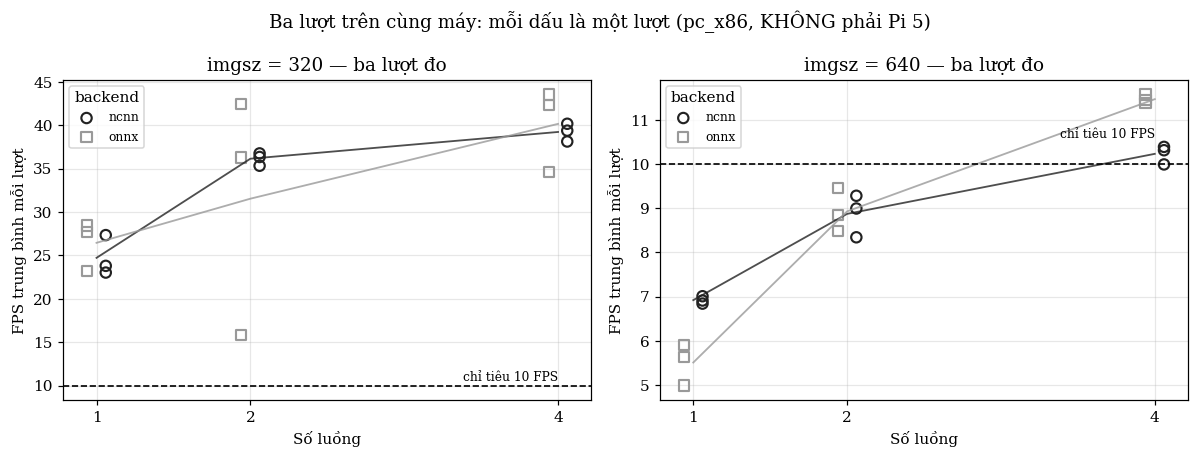

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

for ax, k in zip(axes, kich_thuoc):
    for be, dau, mau in zip(backends, ['o', 's'], ['#222222', '#999999']):
        con = fps_theo_lot[(fps_theo_lot.backend == be) & (fps_theo_lot.imgsz == k)]
        lech = 0.06 if be == backends[0] else -0.06
        ax.scatter(con.threads + lech, con.fps, marker=dau, s=46, facecolors='none',
                   edgecolors=mau, linewidths=1.4, label=be)
        tb = con.groupby('threads').fps.mean()
        ax.plot(tb.index, tb.values, '-', color=mau, linewidth=1.2, alpha=0.8)

    ax.axhline(10, color='black', linestyle='--', linewidth=1.1)
    ax.text(luong[-1], 10.6, 'chỉ tiêu 10 FPS', ha='right', fontsize=8)
    ax.set_xticks(luong)
    ax.set_xlabel('Số luồng')
    ax.set_ylabel('FPS trung bình mỗi lượt')
    ax.set_title(f'imgsz = {k} — ba lượt đo')
    ax.legend(title='backend', fontsize=8)

plt.suptitle('Ba lượt trên cùng máy: mỗi dấu là một lượt (pc_x86, KHÔNG phải Pi 5)')
plt.tight_layout()
plt.show()

In [13]:
cot = ['backend', 'imgsz', 'threads', 'fps_min', 'fps_max', 'biên độ %']
print('Bốn ô nhiễu nhất giữa các lượt:')
print(bang.nlargest(4, 'biên độ %')[cot].to_string(index=False))
print()
print('Bốn ô ổn định nhất:')
print(bang.nsmallest(4, 'biên độ %')[cot].to_string(index=False))
print()
print('Biên độ giữa các lượt, gộp theo backend:')
print(bang.groupby('backend')['biên độ %'].agg(['min', 'max', 'mean']).round(1).to_string())

Bốn ô nhiễu nhất giữa các lượt:
backend  imgsz  threads  fps_min  fps_max  biên độ %
   onnx    320        2    15.84    42.49      168.3
   onnx    320        4    34.59    43.53       25.9
   onnx    320        1    23.24    28.47       22.5
   ncnn    320        1    23.03    27.35       18.8

Bốn ô ổn định nhất:
backend  imgsz  threads  fps_min  fps_max  biên độ %
   onnx    640        4    11.39    11.58        1.7
   ncnn    640        1     6.84     7.01        2.5
   ncnn    320        2    35.34    36.76        4.0
   ncnn    640        4     9.99    10.39        4.0

Biên độ giữa các lượt, gộp theo backend:
         min    max  mean
backend                  
ncnn     2.5   18.8   7.7
onnx     1.7  168.3  41.4


## 4. So sánh hai backend — và phép kiểm xem đã đủ căn cứ chưa

Bảng dưới đặt cạnh nhau hai con số cho mỗi cấu hình:

- **chênh lệch %** — NCNN nhanh hơn (hoặc chậm hơn) ONNX bao nhiêu phần trăm
- **dao động lớn nhất %** — mức chênh giữa ba lượt của backend dao động nhiều hơn

Khi con số thứ hai lớn hơn con số thứ nhất, khác biệt quan sát được **nhỏ hơn chính mức dao động của
phép đo**, nên chưa đủ căn cứ để nói backend nào nhanh hơn. Cột cuối ghi `chưa đủ` cho những ô như
vậy.

Đây là phép kiểm tối thiểu, chưa phải kiểm định thống kê đầy đủ. Nhưng nó đủ để chặn một kết luận
kiểu *"NCNN nhanh hơn 8 %"* trong khi đo lại ba lần thì chính con số đó xê dịch 25 %.

In [14]:
truc = bang.pivot_table(index=['imgsz', 'threads'], columns='backend',
                        values=['fps_tb', 'biên độ %'])

so_sanh = pd.DataFrame({
    'onnx fps': truc[('fps_tb', 'onnx')],
    'ncnn fps': truc[('fps_tb', 'ncnn')],
})
so_sanh['chênh lệch %'] = (so_sanh['ncnn fps'] - so_sanh['onnx fps']) / so_sanh['onnx fps'] * 100
so_sanh['dao động lớn nhất %'] = truc['biên độ %'].max(axis=1)
so_sanh['đủ căn cứ?'] = np.where(
    so_sanh['chênh lệch %'].abs() > so_sanh['dao động lớn nhất %'], 'đủ', 'chưa đủ'
)
print(so_sanh.round(1).to_string())
print()
n_du = int((so_sanh['đủ căn cứ?'] == 'đủ').sum())
print(f'{n_du}/{len(so_sanh)} cấu hình có khác biệt lớn hơn mức dao động của phép đo.')
if n_du < len(so_sanh):
    print(f'{len(so_sanh) - n_du} cấu hình còn lại: chênh lệch giữa hai backend nhỏ hơn mức dao '
          'động khi đo lại, nên chưa kết luận được backend nào nhanh hơn.')

               onnx fps  ncnn fps  chênh lệch %  dao động lớn nhất % đủ căn cứ?
imgsz threads                                                                  
320   1            26.5      24.7          -6.5                 22.5    chưa đủ
      2            31.5      36.2          14.6                168.3    chưa đủ
      4            40.2      39.2          -2.3                 25.9    chưa đủ
640   1             5.5       6.9          25.6                 18.4         đủ
      2             8.9       8.9          -0.7                 11.3    chưa đủ
      4            11.5      10.2         -10.8                  4.0         đủ

2/6 cấu hình có khác biệt lớn hơn mức dao động của phép đo.
4 cấu hình còn lại: chênh lệch giữa hai backend nhỏ hơn mức dao động khi đo lại, nên chưa kết luận được backend nào nhanh hơn.


## 5. Độ trễ phân vị 95 — thứ quyết định hệ thống thời gian thực

Trung bình che giấu những khung hình chậm bất thường. Với pipeline chạy liên tục, p95 mới cho biết
trường hợp xấu — thứ người dùng cảm nhận được dưới dạng giật hình.

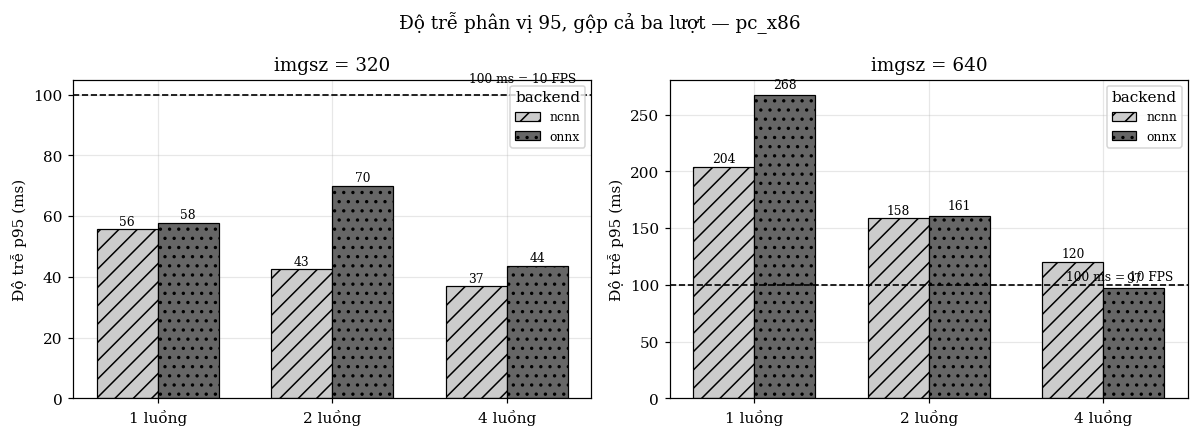

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
rong = 0.35

for ax, k in zip(axes, kich_thuoc):
    x = np.arange(len(luong))
    for i, (be, ht, mau) in enumerate(zip(backends, ['//', '..'], ['#cccccc', '#666666'])):
        gia_tri = [bang[(bang.backend == be) & (bang.imgsz == k)
                        & (bang.threads == t)].lat_p95.iloc[0] for t in luong]
        ax.bar(x + (i - 0.5) * rong, gia_tri, rong, label=be, color=mau,
               edgecolor='black', linewidth=0.8, hatch=ht)
        for xi, v in zip(x + (i - 0.5) * rong, gia_tri):
            ax.text(xi, v + max(gia_tri) * 0.02, f'{v:.0f}', ha='center', fontsize=8)

    ax.axhline(100, color='black', linestyle='--', linewidth=1.1)
    ax.text(len(luong) - 0.6, 104, '100 ms = 10 FPS', ha='right', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{t} luồng' for t in luong])
    ax.set_ylabel('Độ trễ p95 (ms)')
    ax.set_title(f'imgsz = {k}')
    ax.legend(title='backend', fontsize=8)

plt.suptitle('Độ trễ phân vị 95, gộp cả ba lượt — pc_x86')
plt.tight_layout()
plt.show()

## 6. Chất lượng phát hiện

Tốc độ chỉ có nghĩa nếu hai backend tìm ra cùng những khuôn mặt. `P2-04` đã chứng minh điều đó trên
50 ảnh với sai số điểm mốc cỡ 10⁻⁵ pixel; ô dưới kiểm lại trên chính 3 600 khung của ba lượt đo.

In [16]:
chat_luong = (df.groupby(['backend', 'imgsz'])
                .agg(so_khung=('n_faces', 'size'),
                     ti_le_co_mat=('n_faces', lambda s: (s >= 1).mean()),
                     so_mat_tb=('n_faces', 'mean'),
                     conf_tb=('conf_top', 'mean'))
                .round(4))
print(chat_luong.to_string())
print()

# Hai backend chạy cùng tập ảnh, cùng seed -> số mặt phát hiện phải khớp từng khung
truc_mat = df.pivot_table(index=['imgsz', 'threads', 'lot', 'sample_idx'],
                          columns='backend', values='n_faces')
lech = int((truc_mat['onnx'] != truc_mat['ncnn']).sum())
print(f'Số khung hai backend cho số khuôn mặt KHÁC nhau: {lech}/{len(truc_mat)}')

               so_khung  ti_le_co_mat  so_mat_tb  conf_tb
backend imgsz                                            
ncnn    320         900           1.0       1.34   0.8538
        640         900           1.0       1.28   0.8340
onnx    320         900           1.0       1.34   0.8538
        640         900           1.0       1.28   0.8340

Số khung hai backend cho số khuôn mặt KHÁC nhau: 0/1800


## 7. Kết luận

### 7.1. Điều chưa kết luận được

Chưa xác định được backend nào nhanh hơn trên máy phát triển. Ở phần lớn cấu hình, **khác biệt giữa
hai backend nhỏ hơn mức dao động của chính phép đo** khi chạy lại (bảng mục 4).

Đây không phải một phép đo thất bại — nó là kết quả của phép đo, và là bằng chứng bằng số cho thấy
đo trên máy phát triển không thay được đo trên thiết bị đích.

### 7.2. Điều đã kết luận được

- **Mức dao động giữa các lượt của hai backend** — xem bảng gộp theo backend ở mục 3. Đại lượng này
  không phụ thuộc kiến trúc theo cùng cách như tốc độ tuyệt đối, nên nó còn giá trị khi chuyển sang
  ARM.
- **Độ phân giải 640 chỉ vượt 10 FPS khi dùng 4 luồng**, đúng ở cả hai backend và cả ba lượt.
- **Hai backend phát hiện như nhau** (mục 6) — số khuôn mặt khớp trên từng khung hình, phù hợp với
  kết quả đối chiếu của `P2-04`.

### 7.3. Vì sao không nên kết luận Đạt/Không đạt từ một lượt đo

Cấu hình `NCNN 640 / 4 luồng` cho 10,32 · 9,99 · 10,39 FPS qua ba lượt. Đối chiếu với ngưỡng 10 FPS
thì hai lượt "Đạt", một lượt "Không đạt" — cùng một cấu hình, cùng một máy, trong vòng 22 phút.

Bất kỳ chỉ tiêu nào được kết luận từ một lượt đo duy nhất, với giá trị rơi sát ngưỡng, đều có thể
cho kết quả ngược lại ở lần đo sau. Đây là lý do R9 yêu cầu báo cáo giá trị trung bình kèm mức dao
động, thay vì một con số đơn lẻ.

### 7.4. Việc cần làm khi có Raspberry Pi 5

1. Chạy `scripts/benchmark_detect.py --device-name "Raspberry Pi 5 8GB"`, **ba lượt**, cách nhau đủ
   lâu để máy trở về cùng trạng thái nhiệt — không lặp lại khoảng cách 4 phút của lượt 3 lần này
2. Thêm ba tệp đó vào `TEP_LUOT` ở ô đầu, chạy lại toàn bộ notebook
3. Dựng bảng ba môi trường ở `04_so_sanh_moi_truong.ipynb`, gộp theo trường `moi_truong`
4. **Kết luận chọn backend đặt ở đó**, không phải ở đây